# Source MP distributions and cross-dataset overlap

This standalone notebook compares ChemXplore (1), EGNN (2), PATENTS (3), and Bradley (4). It reproduces the source parsing, canonical isomeric SMILES conversion, metal exclusion, and single-component filtering used by `combine_data_process.ipynb`; halogens are retained.

For source-level plots, each canonical compound counts once per source. If a source contains several observations for one SMILES, their within-source median is used for this EDA only.

**PATENTS clarification:** strict numeric intervals are converted to their midpoint during extraction. Later quantities such as MP spread, agreement tiers, or standard deviation are calculated from processed observations across records/sources; they are not extracted from the PATENTS interval.

Outputs shown in the notebook include aligned MP histograms, normalized ECDFs, low/high counts and percentages (high MP is **≥250 °C**), an UpSet-style intersection plot, pairwise overlap/Jaccard heatmaps, and MP-agreement summaries.


In [7]:
from pathlib import Path
import re
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display
from rdkit import Chem, RDLogger

RDLogger.DisableLog('rdApp.*')
DATA_DIR = next(p.resolve() for p in [Path.cwd(), Path.cwd()/'0_data', Path.cwd().parent/'0_data']
                if (p/'sources').exists())
SOURCE_DIR = DATA_DIR/'sources'
NAMES = {1:'1 — ChemXplore', 2:'2 — EGNN', 3:'3 — PATENTS', 4:'4 — Bradley'}
ORDER = list(NAMES)
COLORS = {1:'#3567A8', 2:'#3A9D7D', 3:'#D18A32', 4:'#8A5DA8'}
CLASS_COLORS = {'Low (<250 °C)':'#4C78A8', 'High (≥250 °C)':'#E45756'}
MP_MIN, MP_MAX, HIGH_THRESHOLD = 0.0, 500.0, 250.0
SPECS = [
    (1,'1_ChemXplore_ML_tmp_C.csv','tmp/ºC','chemxplore'),
    (2,'2_EGNN_melt_point.csv','Melt_C','numeric'),
    (3,'3_PATENTS_ochem_enamine_bradley_begstr_m_training_.parquet',
     'Melting Point {measured, converted}','numeric_or_range'),
    (4,'test_predictions.csv','exp MP','numeric'),
    (4,'train_without_data_augmentation.csv','MP','numeric'),
]
plt.style.use('seaborn-v0_8-whitegrid')

NUMBER = r'[+-]?(?:\d+(?:\.\d*)?|\.\d+)'
STRICT_RANGE = re.compile(rf'^\s*({NUMBER})\s*[-–]\s*({NUMBER})\s*$')
CHEM_NUMBER = re.compile(rf'^\s*({NUMBER})(?:\(\d+\))?\s*$')
HALOGENS = {9,17,35,53,85,117}
METAL_SYMBOLS = {
 'Li','Be','Na','Mg','Al','K','Ca','Sc','Ti','V','Cr','Mn','Fe','Co','Ni','Cu','Zn',
 'Ga','Rb','Sr','Y','Zr','Nb','Mo','Tc','Ru','Rh','Pd','Ag','Cd','In','Sn','Cs','Ba',
 'La','Ce','Pr','Nd','Pm','Sm','Eu','Gd','Tb','Dy','Ho','Er','Tm','Yb','Lu','Hf','Ta',
 'W','Re','Os','Ir','Pt','Au','Hg','Tl','Pb','Bi','Po','Fr','Ra','Ac','Th','Pa','U',
 'Np','Pu','Am','Cm','Bk','Cf','Es','Fm','Md','No','Lr','Rf','Db','Sg','Bh','Hs','Mt',
 'Ds','Rg','Cn','Nh','Fl','Mc','Lv'
}
pt = Chem.GetPeriodicTable()
METALS = {pt.GetAtomicNumber(symbol) for symbol in METAL_SYMBOLS}

def parse_mp(value, method):
    if pd.isna(value):
        return np.nan, 'missing'
    text = str(value).strip()
    if method == 'chemxplore':
        match = CHEM_NUMBER.fullmatch(text)
        return (float(match.group(1)), 'numeric') if match else (np.nan, 'censored_or_approximate')
    try:
        return float(text), 'numeric'
    except ValueError:
        if method == 'numeric_or_range':
            match = STRICT_RANGE.fullmatch(text)
            if match:
                low, high = map(float, match.groups())
                return (low+high)/2, 'range_midpoint'
        return np.nan, 'nonnumeric'

def canonicalize(smiles):
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return None, False, False, 0
        smi = Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None, False, False, 0
        smi = Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
        atoms = {atom.GetAtomicNum() for atom in mol.GetAtoms()}
        return smi, bool(atoms & HALOGENS), bool(atoms & METALS), len(Chem.GetMolFrags(mol))
    except Exception:
        return None, False, False, 0

frames, audit = [], []
for source, filename, mp_col, method in SPECS:
    path = SOURCE_DIR/filename
    raw = (pd.read_parquet(path, columns=['SMILES',mp_col]) if path.suffix=='.parquet'
           else pd.read_csv(path, usecols=['SMILES',mp_col], dtype={mp_col:'string'}))
    parsed = raw[mp_col].map(lambda value: parse_mp(value, method))
    frame = pd.DataFrame({
        'Original_SMILES':raw['SMILES'].astype('string'), 'MP_raw':raw[mp_col].astype('string'),
        'MP_reported':parsed.map(lambda x:x[0]), 'Parse_status':parsed.map(lambda x:x[1]),
        'Source':np.int8(source), 'Source_file':filename,
    })
    usable = frame['Original_SMILES'].notna() & frame['MP_reported'].notna()
    audit.append({'Source':source,'Source_name':NAMES[source],'Source_file':filename,
                  'Input_rows':len(frame),'Usable_MP_rows':int(usable.sum()),
                  'Excluded_MP_rows':int((~usable).sum()),
                  'PATENTS_range_midpoints':int(frame['Parse_status'].eq('range_midpoint').sum())})
    frames.append(frame.loc[usable])
observations = pd.concat(frames, ignore_index=True)
display(pd.DataFrame(audit))

unique_raw = observations['Original_SMILES'].drop_duplicates().tolist()
lookup = pd.DataFrame([canonicalize(s) for s in unique_raw],
                      columns=['SMILES','ContainsHalogen','ContainsMetal','NumFragments'])
lookup.insert(0,'Original_SMILES',unique_raw)
observations = observations.merge(lookup,on='Original_SMILES',how='left',validate='many_to_one')
flags = pd.DataFrame({
    'Reason':['Invalid/non-round-trippable SMILES','Contains metal','Multiple components',
              'MP outside 0–500 °C'],
    'Count':[observations['SMILES'].isna().sum(), observations['ContainsMetal'].fillna(False).sum(),
             observations['NumFragments'].fillna(0).ne(1).sum(),
             (~observations['MP_reported'].between(MP_MIN,MP_MAX,inclusive='both')).sum()]
})
display(flags)
keep = (observations['SMILES'].notna() & ~observations['ContainsMetal'].fillna(False)
        & observations['NumFragments'].eq(1)
        & observations['MP_reported'].between(MP_MIN,MP_MAX,inclusive='both'))
observations = (observations.loc[keep]
    .drop_duplicates(['SMILES','MP_reported','Source','Source_file']).reset_index(drop=True))
observations['Source'] = observations['Source'].astype('int8')

source_compounds = (observations.groupby(['Source','SMILES'],as_index=False)
    .agg(MP=('MP_reported','median'),N_observations_in_source=('MP_reported','size'),
         N_distinct_MP_in_source=('MP_reported','nunique')))
source_compounds['Source_name'] = source_compounds['Source'].map(NAMES)
source_compounds['MP_class'] = np.where(source_compounds['MP']>=HIGH_THRESHOLD,
                                        'High (≥250 °C)','Low (<250 °C)')
print(f'Clean observations: {len(observations):,}')
print(f'Canonical compounds across all sources: {observations.SMILES.nunique():,}')
display(source_compounds.groupby('Source')['N_observations_in_source'].apply(
    lambda x:(x>1).sum()).rename('Compounds_with_multiple_within-source_observations').to_frame())


,Source,Source_name,Source_file,Input_rows,Usable_MP_rows,Excluded_MP_rows,PATENTS_range_midpoints
0,1,1 — ChemXplore,1_ChemXplore_ML_tmp_C.csv,7646,7051,595,0
1,2,2 — EGNN,2_EGNN_melt_point.csv,237406,237406,0,0
2,3,3 — PATENTS,3_PATENTS_ochem_enamine_bradley_begstr_m_train...,275133,275045,88,59
3,4,4 — Bradley,test_predictions.csv,1961,1961,0,0
4,4,4 — Bradley,train_without_data_augmentation.csv,17633,17633,0,0


,Reason,Count
0,Invalid/non-round-trippable SMILES,3
1,Contains metal,105
2,Multiple components,928
3,MP outside 0–500 °C,8197


Clean observations: 529,960
Canonical compounds across all sources: 305,002


,Compounds_with_multiple_within-source_observations
Source,
1,0
2,0
3,2
4,6


## Source distributions and low/high MP composition

The histograms use identical 10 °C bins and axis limits. Counts communicate dataset size; the ECDF compares distribution shape independently of size.


,Source_name,Total_compounds,Min_MP,Median_MP,Mean_MP,Max_MP,Low_count,High_count,Low_percent,High_percent
Source,,,,,,,,,,
1,1 — ChemXplore,5123,0.0,99.3,112.87,450.0,4845,278,94.57,5.43
2,2 — EGNN,234818,0.0,147.0,150.42,481.0,220310,14508,93.82,6.18
3,3 — PATENTS,272804,0.0,147.5,152.20,492.5,251746,21058,92.28,7.72
4,4 — Bradley,17207,0.0,120.0,126.02,492.5,16330,877,94.90,5.10


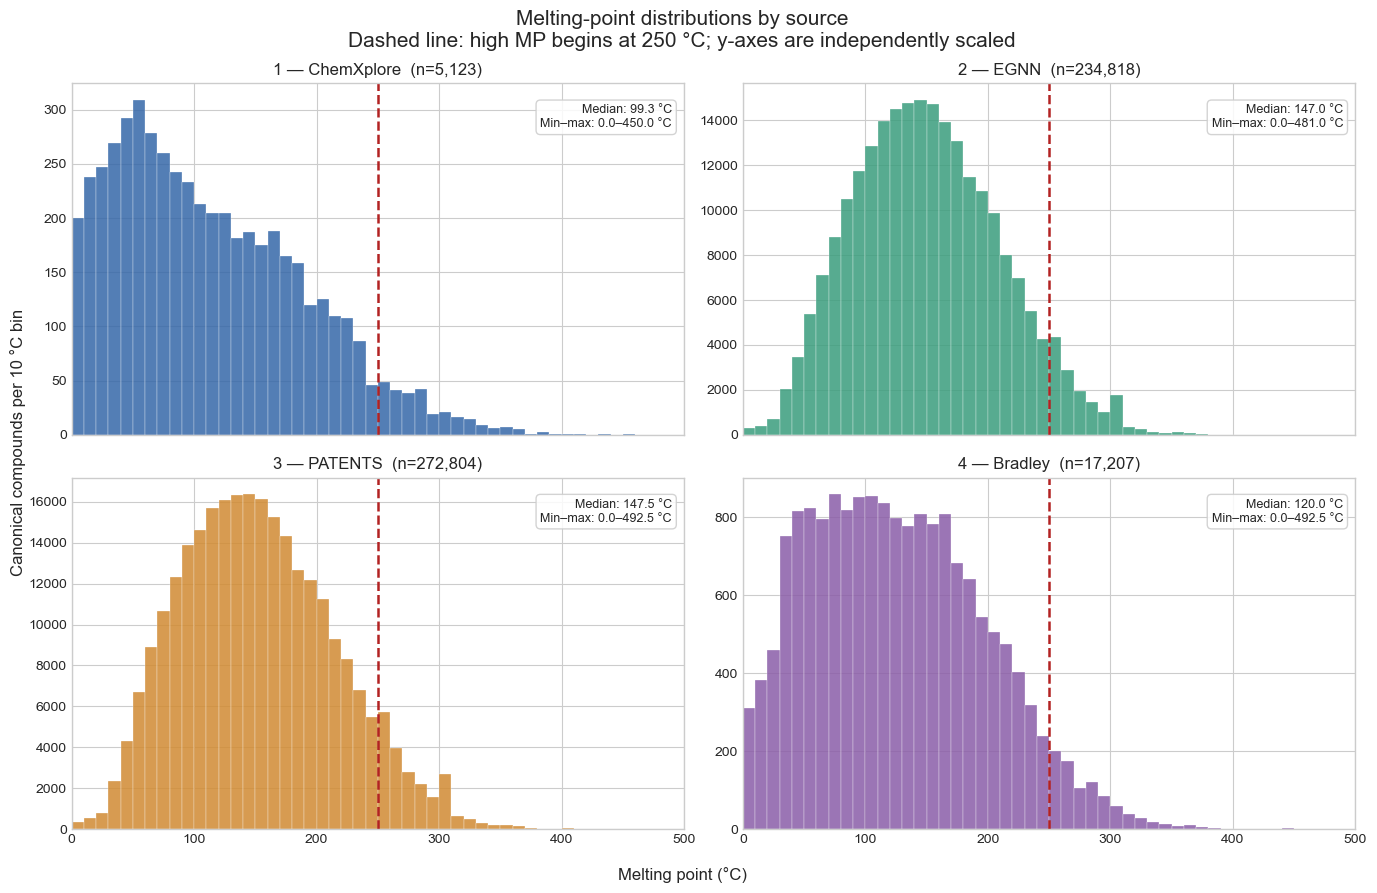

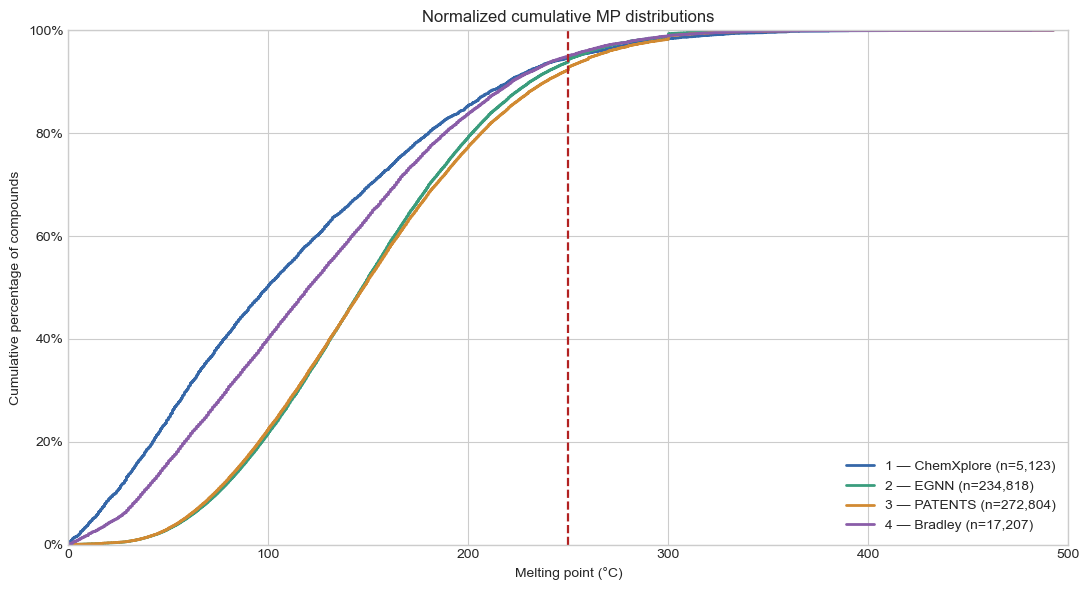

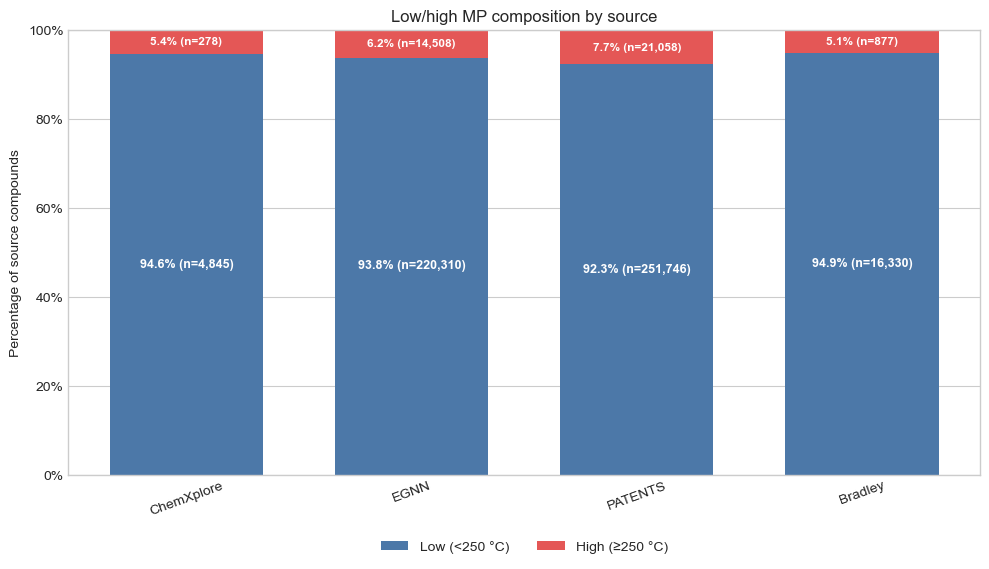

In [12]:
classes = list(CLASS_COLORS)
class_counts = (source_compounds.groupby(['Source','MP_class'],observed=True).size()
                .unstack(fill_value=0).reindex(index=ORDER,columns=classes,fill_value=0))
stats = source_compounds.groupby('Source').agg(
    Total_compounds=('SMILES','nunique'),Min_MP=('MP','min'),Median_MP=('MP','median'),
    Mean_MP=('MP','mean'),Max_MP=('MP','max')).reindex(ORDER)
summary = stats.join(class_counts.rename(columns={classes[0]:'Low_count',classes[1]:'High_count'}))
summary['Low_percent'] = 100*summary['Low_count']/summary['Total_compounds']
summary['High_percent'] = 100*summary['High_count']/summary['Total_compounds']
summary.insert(0,'Source_name',[NAMES[s] for s in summary.index])
display(summary.round(2))

bins = np.arange(MP_MIN,MP_MAX+10,10)
# Independent y-scales keep the smaller ChemXplore and Bradley distributions visible.
fig,axes = plt.subplots(2,2,figsize=(14,9),sharex=True,sharey=False)
for source,ax in zip(ORDER,axes.flat):
    values = source_compounds.loc[source_compounds.Source.eq(source),'MP']
    ax.hist(values,bins=bins,color=COLORS[source],alpha=.85,edgecolor='white',linewidth=.25)
    ax.axvline(HIGH_THRESHOLD,color='#B22222',ls='--',lw=1.8)
    ax.set_title(f'{NAMES[source]}  (n={len(values):,})')
    ax.text(.98,.94,f'Median: {values.median():.1f} °C\nMin–max: {values.min():.1f}–{values.max():.1f} °C',
            transform=ax.transAxes,ha='right',va='top',fontsize=9,
            bbox=dict(boxstyle='round,pad=.35',facecolor='white',alpha=.85,edgecolor='#CCC'))
    ax.set_xlim(MP_MIN,MP_MAX)
fig.supxlabel('Melting point (°C)'); fig.supylabel('Canonical compounds per 10 °C bin')
fig.suptitle('Melting-point distributions by source\nDashed line: high MP begins at 250 °C; y-axes are independently scaled',fontsize=15)
fig.tight_layout(); plt.show()

fig,ax = plt.subplots(figsize=(11,6))
for source in ORDER:
    values = np.sort(source_compounds.loc[source_compounds.Source.eq(source),'MP'].to_numpy())
    ax.step(values,np.arange(1,len(values)+1)/len(values),where='post',
            label=f'{NAMES[source]} (n={len(values):,})',color=COLORS[source],lw=2)
ax.axvline(HIGH_THRESHOLD,color='#B22222',ls='--',lw=1.6)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set(xlim=(MP_MIN,MP_MAX),ylim=(0,1),xlabel='Melting point (°C)',
       ylabel='Cumulative percentage of compounds',title='Normalized cumulative MP distributions')
ax.legend(loc='lower right'); fig.tight_layout(); plt.show()

fig,ax = plt.subplots(figsize=(10,6))
x=np.arange(4)
pct=class_counts.div(class_counts.sum(axis=1),axis=0)*100; bottom=np.zeros(4)
for label in classes:
    vals=pct[label].to_numpy(); counts=class_counts[label].to_numpy()
    bars=ax.bar(x,vals,bottom=bottom,label=label,color=CLASS_COLORS[label],width=.68)
    for rect,val,count,base in zip(bars,vals,counts,bottom):
        label_size = 9 if label == 'Low (<250 °C)' else 8.5
        ax.text(rect.get_x()+rect.get_width()/2,base+val/2,f'{val:.1f}% (n={count:,})',
                ha='center',va='center',color='white',fontweight='bold',fontsize=label_size)
    bottom+=vals
ax.set(title='Low/high MP composition by source',ylabel='Percentage of source compounds',ylim=(0,100))
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_xticks(x,[NAMES[s].split(' — ')[1] for s in ORDER],rotation=20)
ax.legend(loc='upper center',bbox_to_anchor=(0.5,-0.12),ncol=2,frameon=False)
fig.tight_layout(); fig.subplots_adjust(bottom=0.20); plt.show()


## Structural overlap and MP agreement

A **shared structure** has the same canonical isomeric SMILES in multiple source labels, regardless of MP. An **exact MP match** additionally has numerically identical source-level MPs; formatting such as `100` versus `100.0` does not create a difference.

The UpSet-style bars are mutually exclusive intersections and provide the main visual summary of structural overlap. A compact pairwise table is retained afterward because the UpSet plot does not show whether shared structures also have matching MP values.


,Combination,Compounds,N_sources
0,2 & 3,194047,2
1,3,64022,1
2,2,28359,1
3,2 & 3 & 4,7853,3
4,1 & 2 & 3 & 4,3017,4
5,3 & 4,2881,2
6,4,1941,1
7,2 & 4,776,2
8,1,640,1
9,1 & 3 & 4,559,3


Compounds in more than one source: 210,040


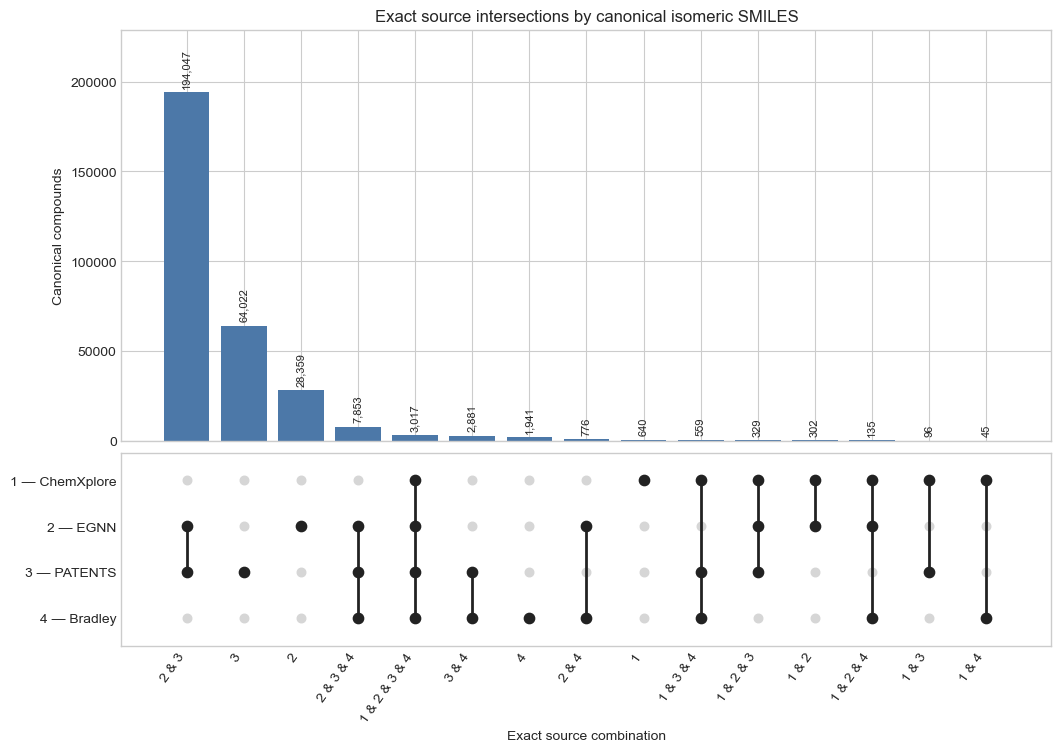

,Source_pair,Shared_SMILES,Exact_MP_matches,Exact_percent,Within_1_C,Within_5_C,Within_10_C,Median_absolute_difference_C,Mean_absolute_difference_C
0,1 & 2,3783,1296,34.26,2489,3498,3643,0.50,2.27
1,1 & 3,4001,1214,30.34,2559,3680,3837,0.55,2.75
2,1 & 4,3756,1259,33.52,2358,3483,3634,0.70,2.17
3,2 & 3,205246,202366,98.60,204203,204862,205023,0.00,0.06
4,2 & 4,11781,9653,81.94,11046,11616,11686,0.00,0.45
5,3 & 4,14310,10069,70.36,12899,13906,14078,0.00,1.10


In [9]:
presence=source_compounds[['SMILES','Source']].drop_duplicates()
memberships=presence.groupby('SMILES')['Source'].agg(lambda x:tuple(sorted(set(map(int,x)))))
intersections=(memberships.value_counts().rename_axis('Sources').reset_index(name='Compounds'))
intersections['Combination']=intersections.Sources.map(lambda x:' & '.join(map(str,x)))
intersections['N_sources']=intersections.Sources.map(len)
intersections=intersections.sort_values(['Compounds','N_sources','Combination'],ascending=[False,False,True]).reset_index(drop=True)
display(intersections[['Combination','Compounds','N_sources']])
print(f'Compounds in more than one source: {memberships.map(len).gt(1).sum():,}')

x=np.arange(len(intersections))
fig=plt.figure(figsize=(max(12,.75*len(x)),8))
gs=fig.add_gridspec(2,1,height_ratios=[3.2,1.5],hspace=.04)
top=fig.add_subplot(gs[0]); matrix=fig.add_subplot(gs[1],sharex=top)
bars=top.bar(x,intersections.Compounds,color='#4C78A8')
top.bar_label(bars,labels=[f'{v:,}' for v in intersections.Compounds],padding=3,fontsize=8,rotation=90)
top.set_ylabel('Canonical compounds'); top.set_title('Exact source intersections by canonical isomeric SMILES')
top.tick_params(axis='x',labelbottom=False); top.margins(y=.18)
for col,sources in enumerate(intersections.Sources):
    rows=[ORDER.index(s) for s in sources]
    matrix.scatter([col]*4,range(4),s=38,color='#D6D6D6',zorder=1)
    matrix.scatter([col]*len(rows),rows,s=55,color='#222',zorder=3)
    if len(rows)>1: matrix.plot([col,col],[min(rows),max(rows)],color='#222',lw=2,zorder=2)
matrix.set_yticks(range(4),[NAMES[s] for s in ORDER])
matrix.set_xticks(x,intersections.Combination,rotation=55,ha='right')
matrix.set_xlabel('Exact source combination'); matrix.set_ylim(-.6,3.6); matrix.invert_yaxis(); matrix.grid(False)
plt.show()

tables={s:source_compounds.loc[source_compounds.Source.eq(s),['SMILES','MP']].rename(columns={'MP':f'MP_{s}'}) for s in ORDER}
agreement=[]
for a,b in combinations(ORDER,2):
    paired=tables[a].merge(tables[b],on='SMILES',validate='one_to_one')
    delta=(paired[f'MP_{a}']-paired[f'MP_{b}']).abs()
    exact=np.isclose(delta,0,rtol=0,atol=1e-12)
    agreement.append({'Source_pair':f'{a} & {b}','Shared_SMILES':len(delta),
      'Exact_MP_matches':int(exact.sum()),'Exact_percent':100*exact.mean() if len(delta) else np.nan,
      'Within_1_C':int((delta<=1).sum()),'Within_5_C':int((delta<=5).sum()),
      'Within_10_C':int((delta<=10).sum()),'Median_absolute_difference_C':delta.median(),
      'Mean_absolute_difference_C':delta.mean()})
pairwise_agreement = pd.DataFrame(agreement)
display(pairwise_agreement.round(2))
